## Маркетинговая атрибуция

На лекции мы увидели, что у одной кампании может быть три разных ROAS. На семинаре подробнее разберем **атрибуцию** — правила, по которым заказ делится между каналами, с которыми пользователь контактировал до покупки.

In [1]:
import itertools
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 14, 'axes.titlepad': 16,
    'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False,
})

import warnings
warnings.filterwarnings('ignore')

### Данные

Сервис доставки еды, два месяца наблюдений. Три таблицы:
- df_touches — касания;
- df_orders — заказы (один заказ на юзера);
- df_costs — спенд на канал.

Данные синтетические. Внутри генератора у каждого пользователя есть скрытое намерение купить, а у каждого канала — истинная прибавка к вероятности заказа. Поэтому генератор знает, сколько заказов действительно добавил каждый канал. 

Таблицу (`df_truth`) мы посмотрим только в конце.

In [2]:
def generate_attribution_data(n_users=60_000, seed=5):
    rng = np.random.default_rng(seed)
    t0 = pd.Timestamp('2026-09-01')

    intent = rng.beta(1.2, 4.0, n_users)        
    p_base = 0.01 + 0.45 * intent ** 2         

    spec = {
        'target_ads':   (np.full(n_users, 0.40), 0.030, (4, 25), 0.30, 2.0),
        'media_ads':    (np.full(n_users, 0.30), 0.010, (6, 28), 0.03, 2.5),
        'rsya':         (0.12 + 0.45 * intent,   0.015, (2, 14), 0.10, 2.4),
        'email':        (0.10 + 0.50 * intent,   0.012, (1, 10), 0.60, 1.6),
        'retargeting':  (0.03 + 1.10 * intent,   0.006, (0, 5),  0.25, 2.2),
        'brand_search': (0.02 + 0.95 * intent,   0.002, (0, 2),  1.00, 1.1),
        'direct':       (0.05 + 0.60 * intent,   0.000, (0, 1),  1.00, 1.0),
    }

    decision = t0 + pd.to_timedelta(rng.uniform(30, 60, n_users), unit='D')
    exposed, touches = {}, []

    for ch, (p_exp, lift, (d_min, d_max), click_share, mean_touches) in spec.items():
        is_exp = rng.random(n_users) < np.clip(p_exp, 0, 0.95)
        exposed[ch] = is_exp
        idx = np.flatnonzero(is_exp)
        k = 1 + rng.poisson(mean_touches - 1, len(idx))
        users = np.repeat(idx, k)
        days_before = rng.uniform(d_min, d_max, len(users))
        ts = (decision[users] - pd.to_timedelta(days_before, unit='D')
              - pd.to_timedelta(rng.uniform(0.01, 0.2, len(users)), unit='D'))
        touch_type = np.where(rng.random(len(users)) < click_share, 'click', 'view')
        touches.append(pd.DataFrame({'user_id': users, 'ts': ts, 'channel': ch, 'touch_type': touch_type}))

    df_touches = pd.concat(touches, ignore_index=True).sort_values(['user_id', 'ts']).reset_index(drop=True)
    df_touches.loc[df_touches.channel == 'direct', 'touch_type'] = 'visit'
    df_touches['ts'] = df_touches.ts.dt.floor('s')

    u = rng.random(n_users)
    lifts = {ch: s[1] for ch, s in spec.items()}
    p_full = p_base + sum(lifts[ch] * exposed[ch] for ch in spec)
    converted = u < p_full
    revenue = np.round(rng.lognormal(7.2, 0.45, n_users), 0)

    df_users = pd.DataFrame({'user_id': np.arange(n_users)})
    df_orders = pd.DataFrame({'user_id': np.flatnonzero(converted),
                              'ts': decision[converted].floor('s'),
                              'revenue': revenue[converted]})
    df_costs = pd.DataFrame({'channel': ['target_ads', 'media_ads', 'rsya', 'email', 'retargeting', 'brand_search'],
                             'spend': [450_000, 250_000, 200_000, 20_000, 180_000, 150_000]})

    truth = {ch: int((converted & ~(u < p_full - lifts[ch] * exposed[ch])).sum()) for ch in spec}
    truth['organic'] = int((u < p_base).sum())
    df_truth = pd.Series(truth, name='truth')

    return df_users, df_touches, df_orders, df_costs, df_truth

In [3]:
df_users, df_touches, df_orders, df_costs, df_truth = generate_attribution_data()

print(f'Пользователей: {len(df_users):};  касаний: {len(df_touches):};  заказов: {len(df_orders):};  '
      f'средний чек: {df_orders.revenue.mean():.0f} руб')

Пользователей: 60000;  касаний: 211540;  заказов: 4272;  средний чек: 1470 руб


In [4]:
df_touches.head(5)

,user_id,ts,channel,touch_type
0,0,2026-09-17 10:48:38,target_ads,click
1,0,2026-10-02 02:37:24,direct,visit
2,1,2026-10-08 21:47:46,target_ads,view
3,1,2026-10-26 02:56:10,retargeting,view
4,1,2026-10-28 12:06:46,brand_search,click


In [27]:
df_touches.channel.unique()

array(['target_ads', 'direct', 'retargeting', 'brand_search', 'email',
       'media_ads', 'rsya'], dtype=object)

In [5]:
df_orders.head(3)

,user_id,ts,revenue
0,11,2026-10-25 13:18:56,1730.0
1,29,2026-10-12 20:37:25,1637.0
2,30,2026-10-18 07:40:35,901.0


In [6]:
(df_touches.groupby('channel')
 .agg(users=('user_id', 'nunique'), touches=('user_id', 'size'), click_share=('touch_type', lambda x: (x != 'view').mean()))
 .join(df_costs.set_index('channel'))
 .sort_values('users', ascending=False).round(2))

,users,touches,click_share,spend
channel,,,,
target_ads,24055,48254,0.30,450000.0
media_ads,17765,44505,0.03,250000.0
retargeting,17337,38101,0.25,180000.0
brand_search,14504,15935,1.00,150000.0
rsya,13571,32636,0.10,200000.0
email,12940,20780,0.60,20000.0
direct,11329,11329,1.00,NaN


### Путь пользователя

**Путь** — упорядоченные по времени касания одного пользователя. Для купивших берем касания в **окне атрибуции** перед заказом; по умолчанию 30 дней, учитываем и клики, и показы. 

Если у заказа в окне нет ни одного касания, источник заказа не определен. Системы аналитики относят такие заказы к прямым заходам, и мы делаем так же: пользователь в любом случае сам открыл приложение, чтобы заказать.

In [7]:
def build_paths(df_touches, df_orders, window_days=30, touch_types=('click', 'view', 'visit')):

    t = df_touches[df_touches.touch_type.isin(touch_types)].merge(
        df_orders.rename(columns={'ts': 'order_ts'}), on='user_id', how='left')
    t['converted'] = t.order_ts.notna()

    in_window = ~t.converted | ((t.ts <= t.order_ts) & (t.ts >= t.order_ts - pd.Timedelta(days=window_days)))
    t = t[in_window]

    no_touch = df_orders[~df_orders.user_id.isin(t[t.converted].user_id)]
    t = pd.concat([t, pd.DataFrame({
        'user_id': no_touch.user_id, 'ts': no_touch.ts, 'channel': 'direct', 'touch_type': 'visit',
        'order_ts': no_touch.ts, 'revenue': no_touch.revenue, 'converted': True})], ignore_index=True)

    t = t.sort_values(['user_id', 'ts']).reset_index(drop=True)
    t['days_to_order'] = (t.order_ts - t.ts).dt.total_seconds() / 86400
    
    return t

In [8]:
paths = build_paths(df_touches, df_orders)

n_orders = len(df_orders)
n_with_ads = paths[paths.converted & (paths.channel != 'direct')].user_id.nunique()
path_len = paths[paths.converted].groupby('user_id').size()

print(f'Заказов: {n_orders:};  из них с рекламными касаниями в окне: {n_with_ads:} ({n_with_ads / n_orders:.0%})')
print(f'Длина пути перед заказом: медиана {path_len.median():.0f}, среднее {path_len.mean():.1f}, максимум {path_len.max()}')

Заказов: 4272;  из них с рекламными касаниями в окне: 4036 (94%)
Длина пути перед заказом: медиана 4, среднее 4.8, максимум 17


In [9]:
paths[paths.user_id == 32547][['user_id', 'ts', 'channel', 'touch_type', 'days_to_order', 'revenue']]

,user_id,ts,channel,touch_type,days_to_order,revenue
114266,32547,2026-10-02 15:49:07,media_ads,view,26.297488,1041.0
114267,32547,2026-10-08 20:37:34,target_ads,view,20.097176,1041.0
114268,32547,2026-10-16 03:00:56,rsya,view,12.830949,1041.0
114269,32547,2026-10-20 16:08:02,rsya,view,8.284352,1041.0
114270,32547,2026-10-24 10:48:24,email,click,4.506319,1041.0
114271,32547,2026-10-28 05:24:55,brand_search,click,0.730961,1041.0
114272,32547,2026-10-28 19:58:39,direct,visit,0.124201,1041.0


Перед нами один заказ и семь касаний шести каналов. Кому из них записать этот заказ? От ответа зависит ROAS каждого канала и бюджет следующего месяца.

### Классические правила атрибуции

Правило назначает каждому касанию в пути вес $w_k$ — долю заказа, которую получает его канал. В пути $n$ касаний, $k = 1, \dots, n$, веса в сумме дают единицу.

| Правило | Вес | Идея |
|---|---|---|
| **Last click** | $w_n = 1$ | заказ достается последнему касанию |
| **Last non-direct click** | $w = 1$ у последнего касания, которое не прямой заход | то же, но прямой заход не считается каналом |
| **First click** | $w_1 = 1$ | заказ достается первому касанию |
| **Linear** | $w_k = \dfrac{1}{n}$ | поровну всем |
| **Time decay** | $w_k \propto 2^{-\Delta t_k / h}$ | чем ближе к заказу, тем больше; $\Delta t_k$ — дни до заказа, $h$ — период полураспада (7 дней) |
| **Position-based** | $w_1 = w_n = 0.4$, остальным $\dfrac{0.2}{n-2}$ | первому и последнему по 40%, середине остаток |

В time decay веса нормируются на сумму. В position-based при одном касании оно получает все, при двух — по половине.

In [10]:
RULES = ['last_click', 'last_non_direct', 'first_click', 'linear', 'time_decay', 'position_based']


def rule_weights(channels, days_to_order, rule, half_life=7):

    n = len(channels)
    w = np.zeros(n)

    if rule == 'last_click':
        w[-1] = 1
    elif rule == 'last_non_direct':
        non_direct = [i for i, ch in enumerate(channels) if ch != 'direct']
        w[non_direct[-1] if non_direct else -1] = 1
    elif rule == 'first_click':
        w[0] = 1
    elif rule == 'linear':
        w[:] = 1 / n
    elif rule == 'time_decay':
        w = 2 ** (-np.asarray(days_to_order) / half_life)
        w = w / w.sum()
    elif rule == 'position_based':
        if n == 1:
            w[0] = 1
        elif n == 2:
            w[:] = 0.5
        else:
            w[0] = w[-1] = 0.4
            w[1:-1] = 0.2 / (n - 2)
    return w


def show_weights(paths, user_id):

    p = paths[paths.user_id == user_id]
    table = pd.DataFrame({'channel': p.channel.values, 'days_to_order': p.days_to_order.round(1).values})
    for rule in RULES:
        table[rule] = rule_weights(p.channel.tolist(), p.days_to_order.to_numpy(), rule).round(2)
    return table

#### Три пути

Прежде чем считать по всем заказам, посмотрим на веса в трех путях разной формы.

**Путь 1.** Семь касаний, шесть каналов: от медийной рекламы до прямого захода.

In [11]:
show_weights(paths, 32547)

,channel,days_to_order,last_click,last_non_direct,first_click,linear,time_decay,position_based
0,media_ads,26.3,0.0,0.0,1.0,0.14,0.02,0.40
1,target_ads,20.1,0.0,0.0,0.0,0.14,0.04,0.04
2,rsya,12.8,0.0,0.0,0.0,0.14,0.08,0.04
3,rsya,8.3,0.0,0.0,0.0,0.14,0.13,0.04
4,email,4.5,0.0,0.0,0.0,0.14,0.18,0.04
5,brand_search,0.7,0.0,1.0,0.0,0.14,0.27,0.04
6,direct,0.1,1.0,0.0,0.0,0.14,0.28,0.40


Медийная реклама получает от 0 до 100% заказа, прямой заход — тоже от 0 до 100%. Last non-direct отличается от last click только тем, что отдает заказ брендовому поиску вместо прямого захода. Time decay оставляет первому касанию 2%: оно было за 26 дней до заказа, это почти четыре периода полураспада.

**Путь 2.** Два канала, четыре касания: канал встречается в пути несколько раз.

In [12]:
show_weights(paths, 4017)

,channel,days_to_order,last_click,last_non_direct,first_click,linear,time_decay,position_based
0,target_ads,12.3,0.0,0.0,1.0,0.25,0.11,0.4
1,retargeting,2.9,0.0,0.0,0.0,0.25,0.28,0.1
2,retargeting,2.7,0.0,0.0,0.0,0.25,0.29,0.1
3,retargeting,1.4,1.0,1.0,0.0,0.25,0.32,0.4


В linear и time decay канал получает вес за каждое касание, поэтому тот, кто показывается чаще, набирает больше. Ретаргетинг здесь получает три четверти заказа в linear и 89% в time decay просто потому, что показался три раза.

**Путь 3.** Единственное касание.

In [13]:
show_weights(paths, 225)

,channel,days_to_order,last_click,last_non_direct,first_click,linear,time_decay,position_based
0,target_ads,23.4,1.0,1.0,1.0,1.0,1.0,1.0


Когда касание одно, все правила согласны. Спор между моделями идет только о длинных путях — а их большинство: медиана длины пути перед заказом равна 4.

### Канал x модель

Теперь применим каждое правило ко всем заказам и сложим веса по каналам. Получится число заказов, атрибуцированных каналу.

In [14]:
def attribute(paths, rule, half_life=7):

    result = {}
    for _, p in paths[paths.converted].groupby('user_id', sort=False):
        w = rule_weights(p.channel.tolist(), p.days_to_order.to_numpy(), rule, half_life)
        for ch, w_k in zip(p.channel, w):
            result[ch] = result.get(ch, 0) + w_k
    return pd.Series(result)

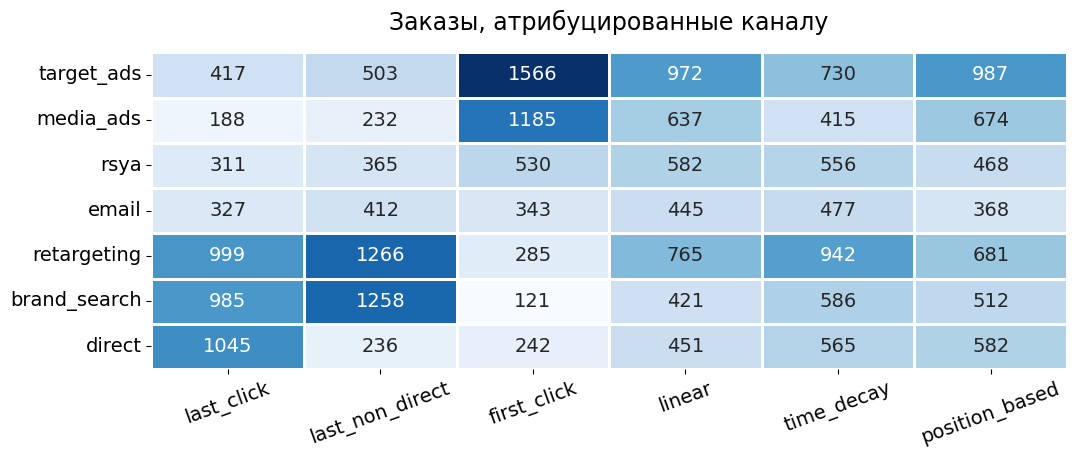

Сумма по каждому правилу: 4272


In [15]:
CHANNEL_ORDER = ['target_ads', 'media_ads', 'rsya', 'email', 'retargeting', 'brand_search', 'direct']

rules_table = pd.DataFrame({rule: attribute(paths, rule) for rule in RULES}).reindex(CHANNEL_ORDER).fillna(0)

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.heatmap(rules_table, annot=True, fmt='.0f', cmap='Blues', cbar=False, linewidths=1, ax=ax, annot_kws={'size': 14})
ax.set_title('Заказы, атрибуцированные каналу')
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print('Сумма по каждому правилу:', rules_table.sum().round(0).astype(int).unique().item())

Все шесть правил распределили между каналами одни и те же заказы, всего 4 272.

Между каналами заказы поделены по-разному:
- **Таргетированная реклама** получает от 417 заказов (last click) до 1 566 (first click) — разница в 3.8 раза.
- **Медийная реклама** — от 188 до 1 185, в 6.3 раза.
- **Брендовый поиск** — от 121 (first click) до 1 258 (last non-direct click), в 10 раз.
- **Прямой заход**: 1 045 в last click и 236 в last non-direct. Заказы переходят предыдущему касанию, чаще всего брендовому поиску и ретаргетингу.
- Linear, time decay и position-based дают промежуточные ответы, но и между ними таргетированная реклама получает от 730 до 987 заказов.

Данные одни и те же. Меняется только правило.

### Почему ответы расходятся: позиция канала в пути

Каждое правило награждает определенное место в пути. Значит, чтобы понять, кому правило выгодно, достаточно посмотреть, где в пути обычно стоит канал.

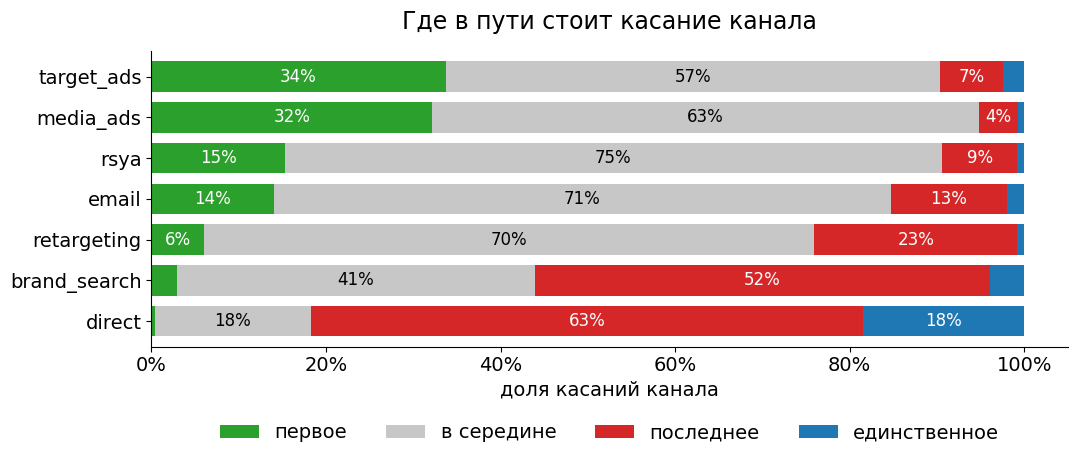

In [16]:
conv = paths[paths.converted].copy()
conv['n'] = conv.groupby('user_id').channel.transform('size')
conv['k'] = conv.groupby('user_id').cumcount()
conv['position'] = np.select(
    [conv.n == 1, conv.k == 0, conv.k == conv.n - 1],
    ['единственное', 'первое', 'последнее'], 'в середине')

position_share = (pd.crosstab(conv.channel, conv.position, normalize='index')
                  .reindex(CHANNEL_ORDER)[['первое', 'в середине', 'последнее', 'единственное']])

ax = position_share.plot(kind='barh', stacked=True, figsize=(11, 5), width=0.75,
                         color=['#2ca02c', '#c7c7c7', '#d62728', '#1f77b4'])

for container, text_color in zip(ax.containers, ['white', 'black', 'white', 'white']):
    labels = [f'{v:.0%}' if v >= 0.04 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', color=text_color, fontsize=12)

ax.invert_yaxis()
ax.set_title('Где в пути стоит касание канала')
ax.set_xlabel('доля касаний канала'); ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

- **Таргетированная и медийная реклама чаще остальных открывают путь:** 34% и 32% их касаний первые, у остальных каналов не больше 15%. Их награждают first click и position-based.
- **Прямой заход и брендовый поиск закрывают путь:** 63% и 52% касаний последние. Их награждает last click.
- **РСЯ, email и ретаргетинг стоят в середине** (70%–75% касаний). Им выгодны linear и time decay, а position-based оставляет им остаток.

Правило оценивает не канал, а позицию. Позиция же определяется механикой канала: охватная реклама знакомит с сервисом, а название сервиса в поиске человек набирает, когда уже решил заказать.

### Настройки: окно атрибуции и учет показов

До сих пор мы меняли правило при фиксированных настройках: окно 30 дней, учитываются и клики, и показы. Настройки выбирают реже и обсуждают меньше, чем модель.

**Что изменится сильнее: если сменить правило или если сменить настройки?**

Проверим на одном правиле, last non-direct click, три варианта настроек.

In [17]:
settings = {
    '30 дней, клики и показы': dict(window_days=30),
    '7 дней, клики и показы': dict(window_days=7),
    '30 дней, только клики': dict(window_days=30, touch_types=('click', 'visit')),
}

settings_table = pd.DataFrame({
    name: attribute(build_paths(df_touches, df_orders, **kwargs), 'last_non_direct')
    for name, kwargs in settings.items()
}).reindex(CHANNEL_ORDER).fillna(0)

settings_table.round(0).astype(int)

,"30 дней, клики и показы","7 дней, клики и показы","30 дней, только клики"
target_ads,503,154,435
media_ads,232,27,41
rsya,365,293,95
email,412,363,469
retargeting,1266,1266,489
brand_search,1258,1258,1505
direct,236,911,1238


Правило одно, а картина меняется не меньше, чем при смене правила:

- **Окно 7 дней.** Медийная реклама почти исчезает (232 -> 27), таргетированная теряет больше двух третей (503 -> 154): большинство их касаний происходит раньше чем за неделю до заказа. Эти заказы не исчезают, а переходят в прямой заход: он вырастает с 236 до 911.
- **Только клики.** Медийная реклама и РСЯ почти исчезают (232 -> 41 и 365 -> 95): баннеры видят, но кликают по ним редко. Ретаргетинг падает с 1 266 до 489. Растут брендовый поиск (до 1 505) и прямой заход (до 1 238): им достаются заказы, в которых раньше последним касанием был показ.

Прямой заход в отчетах работает как корзина для всего, что не удалось привязать к рекламе. Чем строже настройки, тем она больше.

Число из атрибуции имеет смысл только с тремя подписями: **правило, окно, типы касаний**. Этим же объясняется, почему сумма заказов по рекламным кабинетам больше числа заказов: у каждого кабинета свои настройки, и каждый засчитывает заказ себе.

### Методы на данных

Все шесть правил назначают веса заранее, не глядя на данные. Методы на данных считают вклад канала из того, как пользователи с этим каналом и без него на самом деле покупали. Два стандартных метода — вектор Шепли и марковская цепь. Оба вызываем из библиотеки.

Обоим методам нужны и пути без заказа: без них нельзя узнать, насколько канал повышает конверсию.

#### Вектор Шепли

Идея из теории кооперативных игр: каналы — игроки, которые вместе зарабатывают конверсию. Вклад канала — средний прирост конверсии от его добавления ко всем возможным наборам остальных каналов.

Пусть $r(T)$ — доля купивших среди пользователей, у которых набор каналов в пути ровно $T$. Для пользователей с набором $S$ вклад канала $i$:

$$
\phi_i(S) = \sum_{T \subseteq S \setminus \{i\}} \frac{|T|!\,\left(|S| - |T| - 1\right)!}{|S|!}\,\bigl(r(T \cup \{i\}) - r(T)\bigr)
$$

Суммируем по пользователям и получаем число заказов канала:

$$
A_i = \sum_{S \ni i} n_S \cdot \phi_i(S)
$$

где $n_S$ — число пользователей с набором $S$. Между каналами делится только превышение над $r(\varnothing)$, конверсией тех, кто рекламы не видел. Остаток назовем **органикой**: это заказы, которые случились бы и без рекламы.

Органика и прямой заход — разные вещи. Прямой заход описывает, *как* пользователь пришел: сам открыл приложение. Органика описывает, *почему* случился заказ: без влияния рекламы. Человек, которого привела реклама, тоже может прийти прямым заходом, а человек, который заказал бы в любом случае, мог по дороге кликнуть на объявление.

Два упрощения метода: порядок касаний и их число не учитываются, важен только набор каналов. Прямой заход в игру не входит: это не рекламный канал.

In [18]:
# !pip install marketing-attribution-models==2.1.1
import polars as pl
from mam.core import MAM

In [19]:
# формат session: одна строка — одно касание, conversion = True на последнем касании купившего
df_sessions = paths[paths.channel != 'direct'][['user_id', 'ts', 'channel', 'converted']].copy()
is_last = df_sessions.groupby('user_id').cumcount(ascending=False) == 0
df_sessions['conversion'] = df_sessions.converted & is_last
df_sessions['user_id'] = df_sessions.user_id.astype(str)

In [28]:
df_sessions

,user_id,ts,channel,converted,conversion
0,0,2026-09-17 10:48:38,target_ads,False,False
2,1,2026-10-08 21:47:46,target_ads,False,False
3,1,2026-10-26 02:56:10,retargeting,False,False
4,1,2026-10-28 12:06:46,brand_search,False,False
6,1,2026-10-29 10:45:17,retargeting,False,False
...,...,...,...,...,...
211718,59998,2026-10-15 01:24:28,rsya,False,False
211719,59998,2026-10-15 05:36:36,retargeting,False,False
211720,59998,2026-10-17 10:07:33,retargeting,False,False
211721,59998,2026-10-19 08:56:05,retargeting,False,False


In [20]:
mam = MAM(
    df=pl.from_pandas(df_sessions[['user_id', 'ts', 'channel', 'conversion']]),
    format_type='session',
    channels_colname='channel',
    journey_with_conv_colname='conversion',
    datetime_colname='ts',
    user_id_colname='user_id',
)

In [21]:
res_shapley = mam.run_shapley(max_size=6, value_column='conv_rate')
shapley_lib = res_shapley.to_polars().to_pandas().set_index('channels')['attribution']

In [30]:
shapley_lib.sum()

4036.0000000000005

In [31]:
shapley_lib

channels
target_ads      1037.091019
retargeting      862.889176
brand_search     684.784672
rsya             526.918529
email            498.607689
media_ads        425.708914
Name: attribution, dtype: float64

Поправка на органику

In [22]:
# набор рекламных каналов каждого пользователя
channel_sets = paths[paths.channel != 'direct'].groupby('user_id').channel.agg(set)

# конверсия пользователей без рекламы
no_ads = ~df_users.user_id.isin(channel_sets.index)
r0 = df_users[no_ads].user_id.isin(df_orders.user_id).mean()

# каждый пользователь с рекламой отдает органике r0, поровну от каждого канала своего набора
exploded = channel_sets.explode().to_frame('channel')
exploded['share'] = 1 / exploded.groupby(level=0).channel.transform('size')
organic_part = r0 * exploded.groupby('channel').share.sum()

shapley = shapley_lib - organic_part
shapley['organic'] = r0 * len(df_users)

shapley.round(0).astype(int).to_frame('shapley')

,shapley
brand_search,521
email,348
media_ads,196
retargeting,661
rsya,368
target_ads,707
organic,1471


#### Марковская цепь

Пути превращаются в граф переходов. Состояния: старт, каждый канал, заказ и ушел без заказа. Вероятность перехода оценивается по частотам:

$$
p_{ij} = \frac{\text{число переходов } i \to j}{\text{число всех переходов из } i}
$$

По графу считается вероятность дойти от старта до заказа, $P(\text{conv})$. Вклад канала измеряется **эффектом удаления**: канал убирают из графа, все переходы в него направляют в ушел без заказа и смотрят, насколько упала вероятность заказа:

$$
RE_i = 1 - \frac{P(\text{conv} \mid \text{канал } i \text{ удален})}{P(\text{conv})}
$$

Заказы делятся между каналами пропорционально эффектам удаления:

$$
A_i = \text{Conversions} \cdot \frac{RE_i}{\sum_j RE_j}
$$

В отличие от Шепли, метод учитывает порядок касаний. Но органику он не выделяет: между каналами делятся все заказы, у которых был путь.

In [23]:
CHANNEL_ORDER = ['target_ads', 'media_ads', 'rsya', 'email', 'retargeting', 'brand_search', 'direct']
MARKETING = [ch for ch in CHANNEL_ORDER if ch != 'direct']

res_markov = mam.run_markov(transition_to_same_state=False)

res = res_markov.to_polars()
markov = pd.Series(res['attribution'].to_list(), index=res['channels'].to_list())
removal_effect = res_markov.metadata['removal_effect'].iloc[:, 0] 

print(f'Сумма по каналам: {markov.sum():,.0f}')
pd.DataFrame({'removal_effect': removal_effect, 'markov': markov}).reindex(MARKETING).round(3)

Сумма по каналам: 4,036


,removal_effect,markov
target_ads,0.490,1126.803
media_ads,0.381,649.682
rsya,0.331,551.981
email,0.289,394.095
retargeting,0.457,885.579
brand_search,0.352,427.860


### Общая таблица и сверка с истиной

Соберем все восемь моделей в одну таблицу и добавим столбец, который до сих пор был закрыт: **истинный вклад** канала из генератора — сколько заказов пропало бы, если бы канал выключили.

In [24]:
final = rules_table.copy()
final['shapley'] = shapley
final['markov'] = markov
final['truth'] = df_truth
final.loc['organic'] = np.nan
final.loc['organic', ['shapley', 'truth']] = shapley['organic'], df_truth['organic']

final.round(0).astype('Int64')

,last_click,last_non_direct,first_click,linear,time_decay,position_based,shapley,markov,truth
target_ads,417,503,1566,972,730,987,707,1127,723
media_ads,188,232,1185,637,415,674,196,650,184
rsya,311,365,530,582,556,468,368,552,204
email,327,412,343,445,477,368,348,394,157
retargeting,999,1266,285,765,942,681,661,886,107
brand_search,985,1258,121,421,586,512,521,428,30
direct,1045,236,242,451,565,582,<NA>,<NA>,0
organic,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1471,<NA>,2885


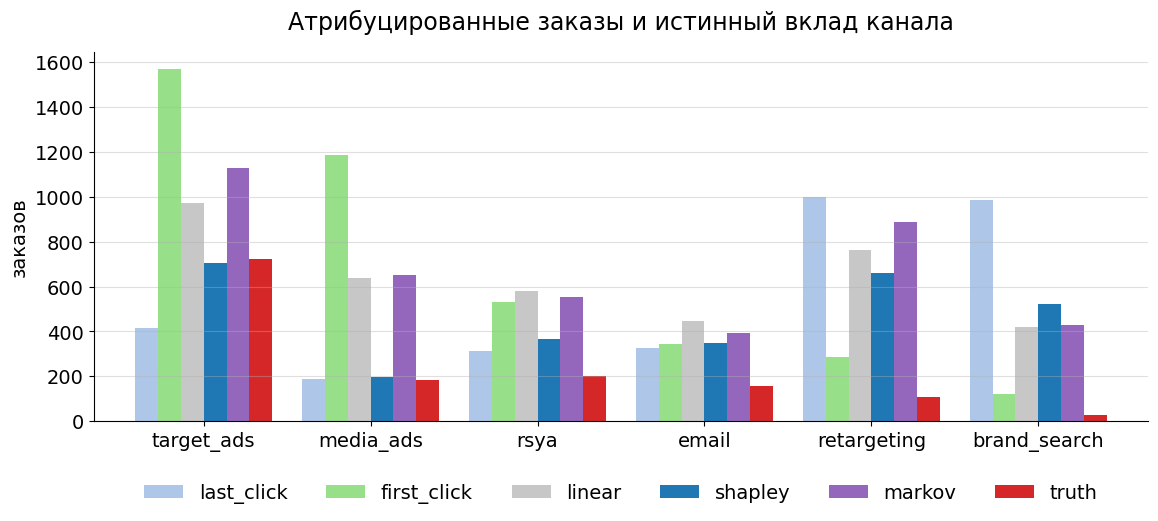

In [25]:
compare = final.loc[MARKETING, ['last_click', 'first_click', 'linear', 'shapley', 'markov', 'truth']]

ax = compare.plot(kind='bar', figsize=(12, 5.5), width=0.82,
                  color=['#aec7e8', '#98df8a', '#c7c7c7', '#1f77b4', '#9467bd', '#d62728'])

ax.set_title('Атрибуцированные заказы и истинный вклад канала')
ax.set_ylabel('заказов'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=6, frameon=False)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Чем сильнее канал отбирает уже заинтересованных, тем больше он завышен.** Таргетированная и медийная реклама показываются всем подряд и оценены почти точно. РСЯ система показывает тем, кого считает заинтересованными, — и оценка уже завышена. Ретаргетинг и брендовый поиск достаются тем, кто уже решил купить, и получают сильно больше, чем заслуживают.

### Какой канал урезать?

Переведем заказы в деньги. Для каждой модели посчитаем ROAS канала: атрибуцированные заказы, умноженные на средний чек, делим на расход. В последнем столбце инкрементальный ROAS по истинному вкладу.

**Бюджет следующего месяца нужно сократить. Какой канал урезаем первым, глядя только на last click? А какой — зная истину?**

In [26]:
aov = df_orders.revenue.mean()
spend = df_costs.set_index('channel').spend

roas = (final.loc[MARKETING, ['last_click', 'last_non_direct', 'first_click', 'linear', 'shapley', 'markov', 'truth']]
        .mul(aov).div(spend, axis=0).astype(float).round(1))
roas = roas.rename(columns={'truth': 'iROAS (истина)'})
roas.insert(0, 'spend', spend)
roas

,spend,last_click,last_non_direct,first_click,linear,shapley,markov,iROAS (истина)
target_ads,450000,1.4,1.6,5.1,3.2,2.3,3.7,2.4
media_ads,250000,1.1,1.4,7.0,3.7,1.2,3.8,1.1
rsya,200000,2.3,2.7,3.9,4.3,2.7,4.1,1.5
email,20000,24.0,30.3,25.2,32.7,25.6,29.0,11.5
retargeting,180000,8.2,10.3,2.3,6.2,5.4,7.2,0.9
brand_search,150000,9.7,12.3,1.2,4.1,5.1,4.2,0.3


### Итоги

- **Правило атрибуции — это решение, а не измерение.** Одни и те же заказы шесть правил делят по-разному, и каждое систематически награждает свою позицию в пути.
- **Настройки меняют результат не меньше, чем модель.** Окно и учет показов нужно фиксировать и сообщать вместе с числом.
- **Методы на данных убирают произвол в весах, но не смещение отбора.** Чем сильнее канал отбирает уже заинтересованных, тем больше его завышает любая модель, включая Шепли.
- **Причинный вклад дает только эксперимент.** Атрибуция годится, чтобы распределять бюджет внутри канала день ото дня; решения между каналами нужно проверять тестом с контрольной группой.